In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [47]:
Z = 82
E = 10*1000 # MeV
t_edges = np.arange(0, 30, 0.2) # in units of X0

from calo_flash import shoot
results = shoot(E, Z, t_edges)

In [48]:
### add stuff
results['log_Ep1'] = np.log(results['E'] + 1)
results['x'] = results['r'] * np.cos(results['phi'])
results['y'] = results['r'] * np.sin(results['phi'])

In [57]:
### plot point cloud on cylindrical coordinates using plotly
import plotly.express as px
import pandas as pd
N = 10000
subset_indices = np.random.choice(len(results['E']), size=N, replace=False)
subset_results = {k: v[subset_indices] for k, v in results.items()}
df = pd.DataFrame(subset_results)
fig = px.scatter_3d(df, x='x', y='y', z='t', color='E', size='log_Ep1', size_max=5)
fig.update_traces(marker=dict(line=dict(width=0)))
max_range = 20.0
fig.update_layout(
    width=1000,
    height=800,
    scene=dict(
        xaxis=dict(range=[-max_range, max_range]),
        yaxis=dict(range=[-max_range, max_range]),
    )
)
fig.show()


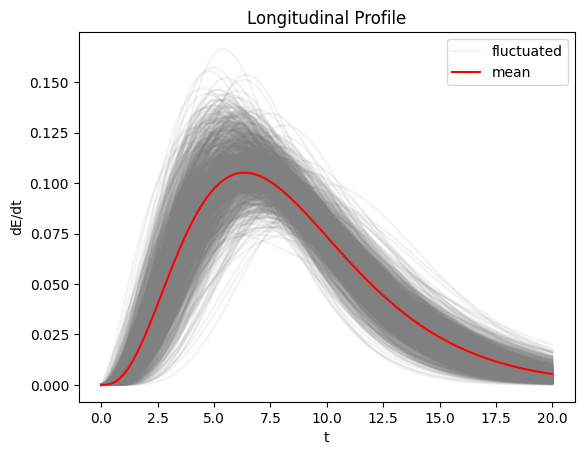

In [ ]:
samples = 1000

from calo_flash import get_longitudinal_parameters, longitudinal_pdf

t = np.linspace(0, 20, 100)
fig, ax = plt.subplots()
for i in range(samples):
    params = get_longitudinal_parameters(E, Z)
    ax.plot(t, longitudinal_pdf(t, params['alpha'], params['beta']), 
            color='grey', alpha=0.1,
            label='fluctuated' if i == 0 else None)
ax.plot(t, longitudinal_pdf(t, params['mean_alpha'], params['mean_beta']), 
        label='mean', color='red')
ax.legend()
ax.set_xlabel('t')
ax.set_ylabel('dE/dt')
ax.set_title('Longitudinal Profile')
plt.show()

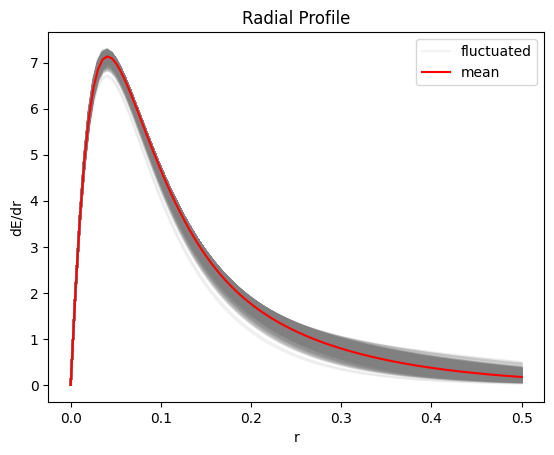

In [61]:
from calo_flash import get_tau, get_radial_parameters, radial_pdf

r = np.linspace(0, 0.5, 100)
fig, ax = plt.subplots()
for i in range(samples):
    long_params = get_longitudinal_parameters(E, Z)
    tau = get_tau(t, long_params['T'], long_params['alpha'], long_params['mean_ln_alpha'])
    R_C, R_T, p = get_radial_parameters(tau, E, Z)
    ax.plot(r, radial_pdf(r, p, R_C, R_T), 
            color='grey', alpha=0.1,
            label='fluctuated' if i == 0 else None)

### Mean profile
tau = get_tau(t, long_params['mean_T'], fluctuate=False)
R_C, R_T, p = get_radial_parameters(tau, E, Z)
ax.plot(r, radial_pdf(r, p, R_C, R_T), 
        label='mean', color='red')
ax.legend()
ax.set_xlabel('r')
ax.set_ylabel('dE/dr')
ax.set_title('Radial Profile')
plt.show()

In [110]:
import numpy as np
from calorimeter import CaloBlock


cfg = {
    'Z': 82,         # Atomic number (Z)
    'height': 2.0,  # Radiation lengths (X0)
    'width': 2.0,   # Radiation lengths (X0)
    'depth': 10.0,   # Radiation lengths (X0)
    'N_cells_transverse': 256,  # Number of cells in x and y
    'N_cells_longitudinal': 8, # Number of cells in z
}

calo = CaloBlock(cfg)

In [111]:
calo.shower(E)

In [112]:
calo.cell_e.shape

(256, 256, 8)

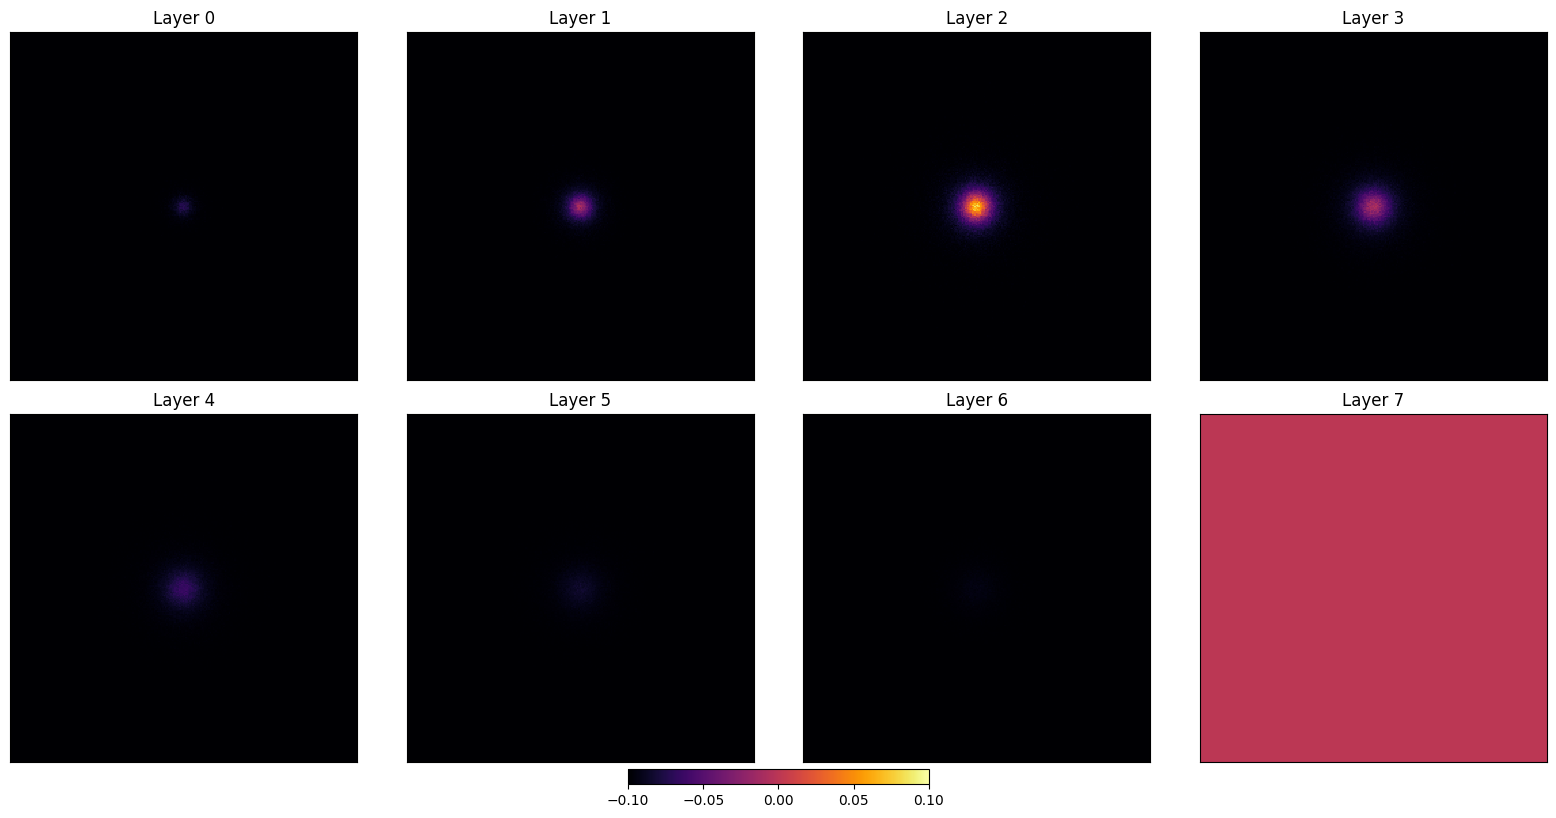

In [113]:
### Plot all 15 layers of the calorimeter with gridspec and imshow
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(20, 20))
gs = gridspec.GridSpec(4, 4, wspace=0.1, hspace=0.1)
for i in range(calo.N_cells_longitudinal):
    ax = fig.add_subplot(gs[i])
    im = ax.imshow(calo.cell_e[:, :, i].T, origin='lower', cmap='inferno', interpolation='none')
    ax.set_title(f'Layer {i}')
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=fig.get_axes(), orientation='horizontal', fraction=0.02, pad=0.01)
plt.show()